In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.20.0
GPU Available: []


In [3]:
DATASET_PATH = r"C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Train: C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset\train
Validation: C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset\val
Test: C:\Users\sujan\Desktop\final project2\DATASET\Processed_RiceDisease_Dataset\test


In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)

Image Size: (224, 224)
Batch Size: 32


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

Found 1811 files belonging to 7 classes.


In [6]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 362 files belonging to 7 classes.


In [7]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 365 files belonging to 7 classes.


In [8]:
class_names = train_ds.class_names

print("Number of Classes:", len(class_names))
print("\nClasses:")

for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

Number of Classes: 7

Classes:
0: bacterial_leaf_blight
1: brown_spot
2: healthy
3: leaf_blast
4: leaf_scald
5: leaf_smut
6: narrow_brown_spot


In [9]:
for images, labels in train_ds.take(1):
    print("Image batch shape :", images.shape)
    print("Label batch shape :", labels.shape)

Image batch shape : (32, 224, 224, 3)
Label batch shape : (32, 7)


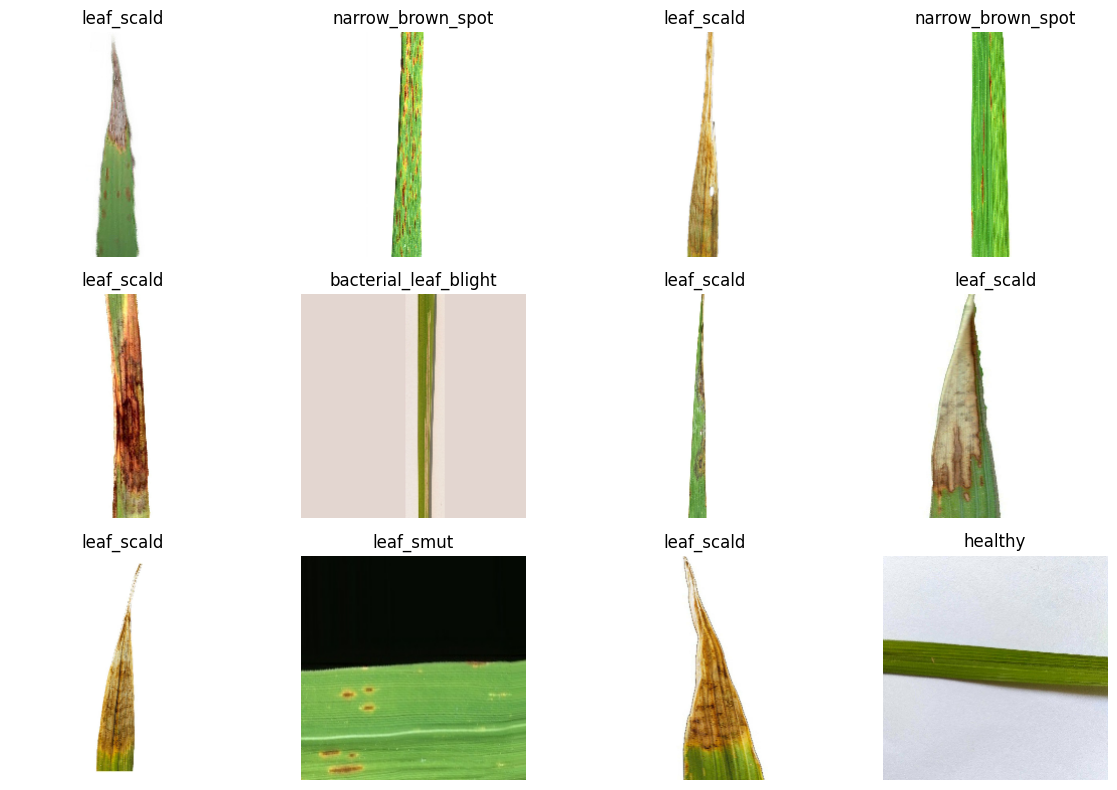

In [10]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):

    for i in range(12):

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label_index = np.argmax(labels[i].numpy())

        plt.title(class_names[label_index])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [26]:
cnn_model = tf.keras.Sequential([

    # Normalize pixel values
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(256, (3,3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Dropout(0.40),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.50),

    layers.Dense(128, activation="relu"),
   

    layers.Dense(7, activation="softmax")

])

In [27]:
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,269,447 (50.62 MB)

 Trainable params: 13,268,487 (50.62 MB)

 Non-trainable params: 960 (3.75 KB)

In [28]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

In [30]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "cnn_best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [31]:
history = cnn_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=15,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.4528 - loss: 5.1627 - val_accuracy: 0.1740 - val_loss: 8.9934 - learning_rate: 0.0010
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.4528 - loss: 1.7482 - val_accuracy: 0.1740 - val_loss: 15.7224 - learning_rate: 0.0010
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.5146 - loss: 1.3242 - val_accuracy: 0.2017 - val_loss: 9.5854 - learning_rate: 0.0010
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5458 - loss: 1.2619
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
57/57 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.5483 - loss: 1.2469 - val_accuracy: 0.1050 - val_loss: 10.2158 - learning_rate: 0.0010
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.6035 - loss: 1.0126 - val_accuracy: 0.0801 - val_loss: 9.1194 - learning_rate: 2.0000e-04
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.6273 - loss: 0.9305 - val

In [19]:
import numpy as np

predictions = cnn_model.predict(test_ds)
predicted_classes = np.argmax(predictions, axis=1)

unique, counts = np.unique(predicted_classes, return_counts=True)

print(dict(zip(unique, counts)))

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 369ms/step
{np.int64(3): np.int64(267), np.int64(4): np.int64(98)}


In [32]:
test_loss, test_acc = cnn_model.evaluate(test_ds)

print("Test Accuracy :", test_acc)
print("Test Loss     :", test_loss)

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 366ms/step - accuracy: 0.8164 - loss: 0.5854
Test Accuracy : 0.8164383769035339
Test Loss     : 0.5854280591011047


In [33]:
from sklearn.metrics import classification_report
import numpy as np

y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds])

y_pred = np.argmax(cnn_model.predict(test_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 360ms/step
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.93      0.95      0.94        55
           brown_spot       0.75      0.73      0.74        59
              healthy       0.93      0.77      0.84        66
           leaf_blast       0.66      0.73      0.69        63
           leaf_scald       0.81      0.93      0.86        54
            leaf_smut       0.67      1.00      0.80         6
    narrow_brown_spot       0.89      0.81      0.85        62

             accuracy                           0.82       365
            macro avg       0.80      0.84      0.82       365
         weighted avg       0.82      0.82      0.82       365

